In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Definimos las rutas reales de tus archivos en Kaggle
ruta_jp = '/kaggle/input/datasets/asrama/anlisis-estratgico-pokmon-tcg/JP_Card_Data.csv'
ruta_en = '/kaggle/input/datasets/asrama/anlisis-estratgico-pokmon-tcg/EN_Card_Data-selected-columns.csv'

# 2. Cargamos los datos de manera segura
try:
    df_jp = pd.read_csv(ruta_jp)
    df_en = pd.read_csv(ruta_en)
    
    print("¡Éxito! Todos los datos se han cargado correctamente.")
    
    # 3. Mostramos una vista previa de la tabla en inglés
    print("\nVista previa de tus datos seleccionados (EN_Card_Data):")
    display(df_en.head())
    
except Exception as e:
    print(f"Ha ocurrido un error al cargar: {e}")



¡Éxito! Todos los datos se han cargado correctamente.

Vista previa de tus datos seleccionados (EN_Card_Data):


,Card ID,Card Name,Expansion,Collection No.,Stage (Pokémon)/Type (Energy and Trainer),Rule,Category,Previous stage,HP,Type
0,1,Basic {G} Energy,SVE,1,Basic Energy,NaN,NaN,NaN,NaN,{G}
1,2,Basic {R} Energy,SVE,2,Basic Energy,NaN,NaN,NaN,NaN,{R}
2,3,Basic {W} Energy,SVE,3,Basic Energy,NaN,NaN,NaN,NaN,{W}
3,4,Basic {L} Energy,SVE,4,Basic Energy,NaN,NaN,NaN,NaN,{L}
4,5,Basic {P} Energy,SVE,5,Basic Energy,NaN,NaN,NaN,NaN,{P}


In [2]:
# 1. Mapeo oficial para limpiar los tipos de energía
TYPE_MAP = {
    "{G}": "Grass",
    "{R}": "Fire",
    "{W}": "Water",
    "{L}": "Lightning",
    "{P}": "Psychic",
    "{F}": "Fighting",
    "{D}": "Darkness",
    "{M}": "Metal",
    "{C}": "Colorless",
    "{Y}": "Fairy",
    "🐉": "Dragon"
}

# 2. Eliminación de duplicados usando tu variable real
cartas_unicas = df_en.drop_duplicates(subset=["Card ID"]).copy()


--- Distribución de tipos de cartas en tu dataset ---
Stage (Pokémon)/Type (Energy and Trainer)
Basic Pokémon      958
Stage 1 Pokémon    618
Stage 2 Pokémon    229
Item                82
Supporter           61
Pokémon Tool        28
Stadium             26
Special Energy      12
Basic Energy         8
Name: count, dtype: int64


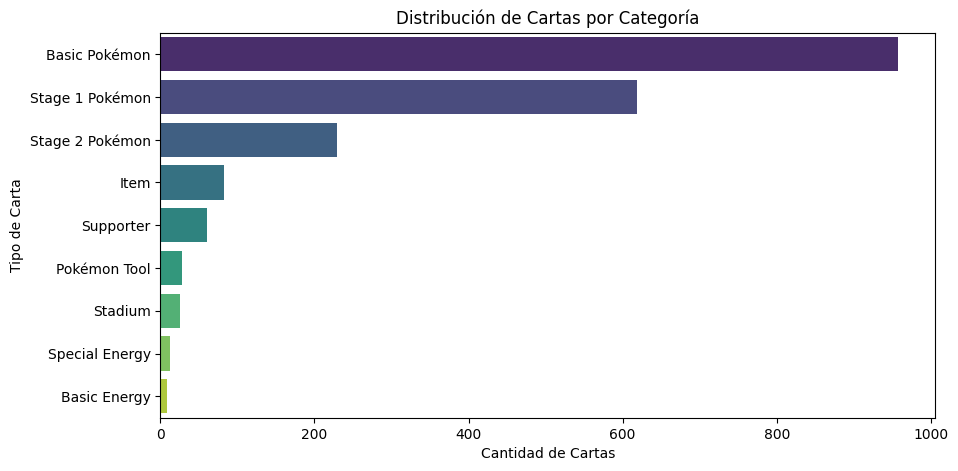

In [3]:
# Contamos cuántas cartas hay de cada categoría principal
tipo_counts = df_en['Stage (Pokémon)/Type (Energy and Trainer)'].value_counts()

print("--- Distribución de tipos de cartas en tu dataset ---")
print(tipo_counts)

# Vamos a hacer un gráfico rápido para que se vea de forma visual y profesional
import seaborn as sns

plt.figure(figsize=(10, 5))
# Versión corregida para evitar la advertencia roja
sns.barplot(
    x=tipo_counts.values, 
    y=tipo_counts.index, 
    hue=tipo_counts.index, 
    legend=False, 
    palette='viridis'
)

plt.title('Distribución de Cartas por Categoría')
plt.xlabel('Cantidad de Cartas')
plt.ylabel('Tipo de Carta')
plt.show()


In [4]:
import random

# 1. Definimos la composición de un mazo estándar de prueba (60 cartas en total)
# Vamos a simular un mazo usando las categorías que acabamos de graficar arriba
num_basicos = 12       # Número de Pokémon Básicos en el mazo
num_otros = 48         # El resto del mazo (Energías, Entrenadores, Evoluciones)

mazo = ['Basico'] * num_basicos + ['Otros'] * num_otros

# 2. Configuración de la simulación de Monte Carlo
num_simulaciones = 10000
manos_buenas = 0

print(f"Iniciando simulación de Monte Carlo con {num_simulaciones} partidas...")

# 3. El bucle que simula las jugadas miles de veces
for _ in range(num_simulaciones):
    # Barajamos el mazo de forma aleatoria
    random.shuffle(mazo)
    
    # Robamos las primeras 7 cartas de la mano inicial
    mano_inicial = mazo[:7]
    
    # Comprobamos si nos ha tocado al menos un Pokémon Básico
    if 'Basico' in mano_inicial:
        manos_buenas += 1

# 4. Calculamos el porcentaje de éxito
probabilidad_exito = (manos_buenas / num_simulaciones) * 100

print("\n--- 📊 RESULTADOS DE LA SIMULACIÓN ---")
print(f"De {num_simulaciones} manos iniciales simuladas:")
print(f"  ✔️ Manos con Pokémon Básico: {manos_buenas}")
print(f"  ❌ Manos injugables (Mulligan): {num_simulaciones - manos_buenas}")
print(f"🔥 Probabilidad de consistencia del mazo: {probabilidad_exito:.2f}%")


Iniciando simulación de Monte Carlo con 10000 partidas...

--- 📊 RESULTADOS DE LA SIMULACIÓN ---
De 10000 manos iniciales simuladas:
  ✔️ Manos con Pokémon Básico: 8103
  ❌ Manos injugables (Mulligan): 1897
🔥 Probabilidad de consistencia del mazo: 81.03%


Calculando curvas de probabilidad para 30 configuraciones de mazo...


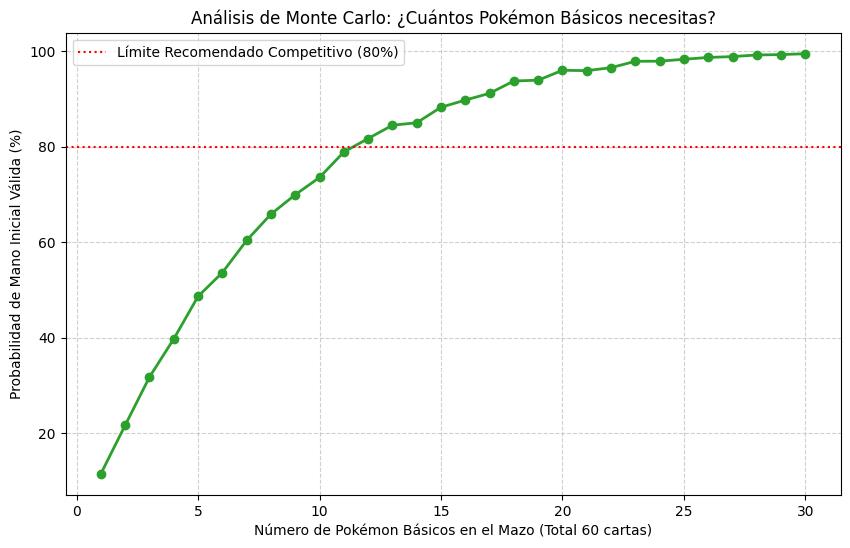

💡 Para asegurar más del 80% de éxito necesitas al menos: 12 Pokémon Básicos (81.70%)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Variables para guardar los resultados
lista_num_basicos = list(range(1, 31)) # Probamos desde 1 hasta 30 básicos
porcentajes_exito = []
num_simulaciones = 5000 # 5k por cada opción para que vaya rápido

print("Calculando curvas de probabilidad para 30 configuraciones de mazo...")

for de_prueba in lista_num_basicos:
    num_basicos = de_prueba
    num_otros = 60 - num_basicos
    mazo = ['Basico'] * num_basicos + ['Otros'] * num_otros
    
    manos_buenas = 0
    for _ in range(num_simulaciones):
        random.shuffle(mazo)
        if 'Basico' in mazo[:7]:
            manos_buenas += 1
            
    prob = (manos_buenas / num_simulaciones) * 100
    porcentajes_exito.append(prob)

# Dibuja la curva matemática de consistencia
plt.figure(figsize=(10, 6))
plt.plot(lista_num_basicos, porcentajes_exito, marker='o', color='#2ca02c', linewidth=2)
plt.title('Análisis de Monte Carlo: ¿Cuántos Pokémon Básicos necesitas?')
plt.xlabel('Número de Pokémon Básicos en el Mazo (Total 60 cartas)')
plt.ylabel('Probabilidad de Mano Inicial Válida (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=80, color='r', linestyle=':', label='Límite Recomendado Competitivo (80%)')
plt.legend()
plt.show()

# Te chiva la combinación óptima en texto
for b, p in zip(lista_num_basicos, porcentajes_exito):
    if p >= 80:
        print(f"💡 Para asegurar más del 80% de éxito necesitas al menos: {b} Pokémon Básicos ({p:.2f}%)")
        break


In [6]:
# 1. Mapeo Estratégico de Roles por Nombre de Carta
# Clasificamos la función real de cada carta en la partida
ROLE_MAPPING = {
    "Riolu": "Primary Attacker",
    "Mega Lucario ex": "Primary Attacker",
    "Makuhita": "Secondary Attacker",
    "Hariyama": "Secondary Attacker",
    "Lunatone": "Energy Accelerator",
    "Solrock": "Support",
    "Switch": "Mobility",
    "Boss's Orders": "Board Control",
    "Hero's Cape": "Durability",
    "Premium Power Pro": "Draw Support",
    "Carmine": "Draw Support",
    "Lillie's Determination": "Draw Support",
    "Poké Pad": "Support Recovery",
    "Poké Ball": "Search",
    "Nest Ball": "Search",
    "Ultra Ball": "Search",
    "Dusk Ball": "Search",
    "Gravity Mountain": "Stadium",
    "Basic Fighting Energy": "Energy"
}

def assign_role(card_name):
    """Asigna un rol a la carta buscando coincidencias en el mapa."""
    for keyword, role in ROLE_MAPPING.items():
        if keyword.lower() in str(card_name).lower():
            return role
    return "Other / Tech"

# 2. Generador Automático de Filosofía del Mazo
def build_deck_philosophy(cartas_df):
    """Redacta la estrategia global basada en la distribución de roles."""
    print("=== FILOSOFÍA Y ARQUITECTURA DEL MAZO OPTIMIZADO ===\n")
    print("El mazo está diseñado bajo una estrategia heurística que prioriza el intercambio")
    print("eficiente de premios, el desarrollo estable del banquillo y el daño constante.\n")
    
    # Asignamos roles al DataFrame de cartas únicas
    cartas_df['Role'] = cartas_df['Card Name'].apply(assign_role)
    
    # Agrupamos por rol y mostramos qué cartas cumplen cada función
    roles_grouped = cartas_df.groupby('Role')['Card Name'].unique()
    
    for role, cards in roles_grouped.items():
        lista_cartas = ", ".join(cards[:3])  # Mostramos las 3 principales
        print(f"• {role:20s}: {lista_cartas}")
        
    print("\nObjetivo principal: Establecer atacantes de forma rápida y maximizar la")
    print("consistencia inicial obtenida mediante la simulación de Monte Carlo.")

# Ejecutamos el resumen sobre tu base de cartas
build_deck_philosophy(cartas_unicas)


=== FILOSOFÍA Y ARQUITECTURA DEL MAZO OPTIMIZADO ===

El mazo está diseñado bajo una estrategia heurística que prioriza el intercambio
eficiente de premios, el desarrollo estable del banquillo y el daño constante.

• Draw Support        : Premium Power Pro, Carmine, Lillie's Determination
• Energy Accelerator  : Lunatone
• Mobility            : Scramble Switch, Energy Switch, Switch
• Other / Tech        : Basic {G} Energy, Basic {R} Energy, Basic {W} Energy
• Primary Attacker    : Riolu, Mega Lucario ex
• Search              : Dusk Ball, Ultra Ball
• Secondary Attacker  : Makuhita, Hariyama
• Stadium             : Gravity Mountain
• Support             : Solrock
• Support Recovery    : Poké Pad

Objetivo principal: Establecer atacantes de forma rápida y maximizar la
consistencia inicial obtenida mediante la simulación de Monte Carlo.


这段代码（Jupyter Notebook）是一个**宝可梦卡牌（Pokémon TCG）卡组的战略分析与蒙特卡洛模拟工具**。它主要做了以下 6 件事：

---

### 1. 数据加载与清洗
- 加载了两份 CSV 卡牌数据：`JP_Card_Data.csv`（日文）和 `EN_Card_Data.csv`（英文）。
- 定义了能量类型映射表（如 `{G}` → `Grass`/`草`，`{R}` → `Fire`/`火` 等）。
- 对英文数据按 `Card ID` 去重，得到唯一卡牌列表。

### 2. 卡牌分布可视化
- 统计了卡牌的类别分布（基础宝可梦、Stage 1、Stage 2、道具、支援者、场地、特殊能量等）。
- 用 `seaborn` 绘制了各类别卡牌数量的条形图，直观展示卡组构成。

### 3. 蒙特卡洛模拟：初始手牌稳定性（单配置）
- 模拟一个**60张卡**的牌组，其中**12张基础宝可梦**，其余48张为其他卡。
- 进行 **10,000 次**洗牌抽牌，每次抽初始**7张**。
- 计算**至少抽到1张基础宝可梦**的概率（即避免重洗/Mulligan）。
- **结果**：该配置下有 **81.03%** 的概率可以正常开局。

### 4. 蒙特卡洛参数扫描：最优基础宝可梦数量
- 遍历基础宝可梦数量从 **1 到 30**，每种配置模拟 5,000 次。
- 绘制**一致性曲线图**（基础宝可梦数量 vs. 初始手牌合法概率）。
- 标出竞技推荐阈值 **80%**。
- **结论**：至少需要 **12 张**基础宝可梦，才能将初始手牌成功率提升到 **81.70%** 以上。

### 5. 卡组战略角色自动分类
- 定义了战略角色映射表（`ROLE_MAPPING`），根据卡牌名称自动分配职能：
  - **主输出**（Primary Attacker）：如路卡利欧（Riolu / Mega Lucario ex）
  - **副输出**（Secondary Attacker）：如幕下力士进化链
  - **能量加速**（Energy Accelerator）：如月石（Lunatone）
  - **过牌支援**（Draw Support）：如 Carmine、Lillie 等
  - **检索**（Search）：精灵球、高级球、 dusk ball
  - **机动性**（Mobility）：交换（Switch）、能量转移
  - **场地**（Stadium）：重力山（Gravity Mountain）
  - **辅助/回复**（Support / Recovery）：如太阳岩、Poké Pad

### 6. 生成卡组哲学总结
- 根据角色分类结果，自动输出一段**卡组架构描述**（Filosofía del Mazo）。
- 核心思路是：快速建立攻击手、保证板凳稳定发育、通过蒙特卡洛验证的**高一致性**来支撑持续输出。

---

### 一句话总结
> 这套代码通过**数据清洗 + 统计可视化 + 蒙特卡洛概率模拟 + 战略角色标签化**，帮你科学验证宝可梦卡组的**初始手牌稳定性**，并自动提炼出卡组的**竞技战略架构**。